In [3]:
#1

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

In [5]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

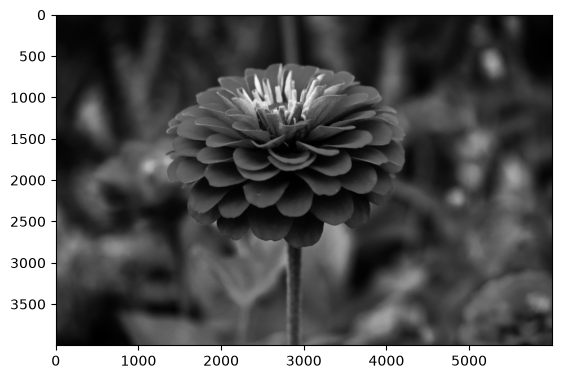

In [6]:
plt.imshow(image_gray, cmap="gray")

In [10]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[100,  17,   0, ...,   0,   0,  22],
       [117,   0,   0, ...,  11,   0,  40],
       [137,   0,  91, ...,   6, 161,  51],
       ...,
       [ 34, 132,   0, ...,   0,   0,  70],
       [128,   0,   0, ...,   2,   0,   0],
       [150,  95,  84, ...,   0,   0,   0]],
      shape=(4000, 6000), dtype=uint8)

In [11]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

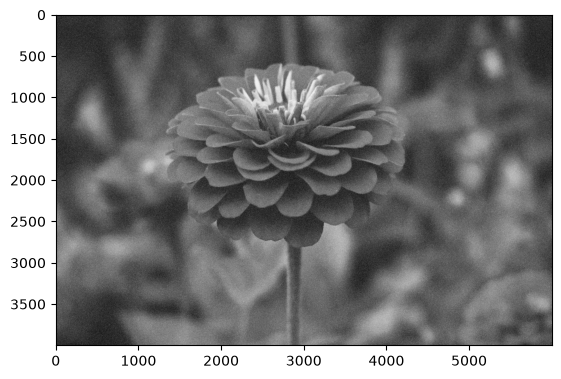

In [12]:
plt.imshow(image_noise_gauss, cmap="gray")

In [13]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
rmse_gauss = np.sqrt(mse_gauss)
ssim_gauss = structural_similarity(image_gray, image_noise_gauss)
print(f"SSIM: {ssim_gauss} RMSE: {rmse_gauss}")

SSIM: 0.025906891159488975 RMSE: 67.09154479360024


In [14]:
# Uniform noise
low = 0
high = 100
noise_uniform = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_uniform, low, high)

array([[71, 23, 84, ..., 46, 26, 60],
       [86, 70, 95, ...,  2, 63, 52],
       [65, 99, 16, ...,  6, 75, 29],
       ...,
       [20, 88, 97, ..., 85, 67, 57],
       [90, 51, 93, ..., 92, 34, 40],
       [94, 98, 67, ..., 22, 92, 37]], shape=(4000, 6000), dtype=uint8)

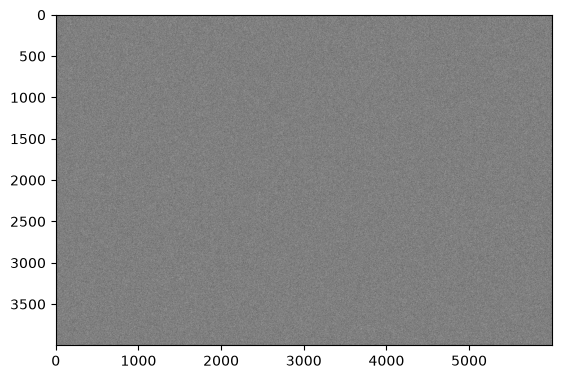

In [16]:
plt.imshow(noise_uniform, cmap="gray")

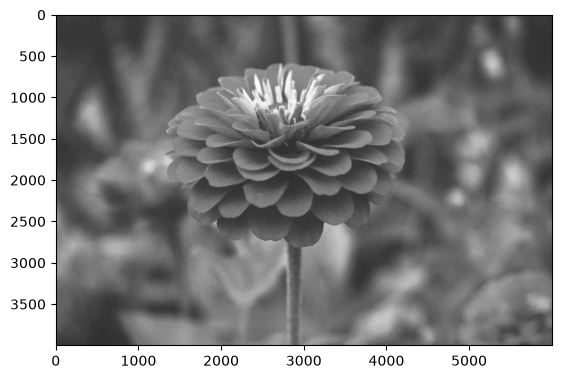

In [17]:
image_noise_uniform = cv2.add(image_gray, noise_uniform)
plt.imshow(image_noise_uniform, cmap="gray")

In [18]:
mse_uniform = mean_squared_error(image_gray, image_noise_uniform)
rmse_uniform = np.sqrt(mse_uniform)
ssim_uniform = structural_similarity(image_gray, image_noise_uniform)
print(f"SSIM: {ssim_uniform} RMSE: {rmse_uniform}")

SSIM: 0.07370039704359765 RMSE: 57.24179040518969


In [19]:
#2

In [20]:
#Median filter

In [21]:
image_uniform_median = cv2.medianBlur(image_noise_uniform, 3)

In [22]:
mse_uniform_median = mean_squared_error(image_gray, image_uniform_median)
rmse_uniform_median = np.sqrt(mse_uniform_median)
ssim_uniform_median = structural_similarity(image_gray, image_uniform_median)
print(f"SSIM: {ssim_uniform:.2f} -> {ssim_uniform_median:.2f} RMSE: {rmse_uniform:.2f} -> {rmse_uniform_median:.2f}")

SSIM: 0.07 -> 0.19 RMSE: 57.24 -> 51.77


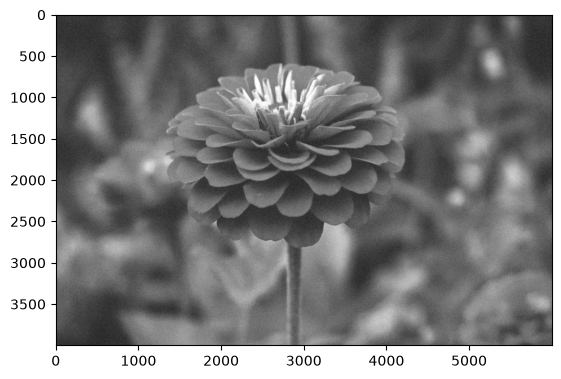

In [23]:
plt.imshow(image_uniform_median, cmap="gray")

In [24]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [25]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
rmse_gauss_median = np.sqrt(mse_gauss_median)
ssim_gauss_median = structural_similarity(image_gray, image_gauss_median)
print(f"SSIM: {ssim_gauss:.2f} -> {ssim_gauss_median:.2f} RMSE: {rmse_gauss:.2f} -> {rmse_gauss_median:.2f}")

SSIM: 0.03 -> 0.15 RMSE: 67.09 -> 29.07


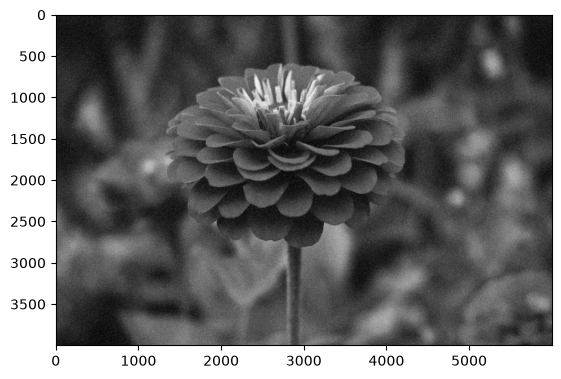

In [26]:
plt.imshow(image_gauss_median, cmap="gray")

In [31]:
image_uniform_median_up = cv2.medianBlur(image_noise_uniform, 5)

In [32]:
mse_uniform_median_up = mean_squared_error(image_gray, image_uniform_median_up)
rmse_uniform_median_up = np.sqrt(mse_uniform_median_up)
ssim_uniform_median_up = structural_similarity(image_gray, image_uniform_median_up)
print(f"SSIM: {ssim_uniform_median:.2f} -> {ssim_uniform_median_up:.2f} RMSE: {rmse_uniform_median:.2f} -> {rmse_uniform_median_up:.2f}")

SSIM: 0.19 -> 0.34 RMSE: 51.77 -> 50.52


In [33]:
#Gaussian filter

In [34]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)

In [35]:
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
rmse_gauss_gauss = np.sqrt(mse_gauss_gauss)
ssim_gauss_gauss = structural_similarity(image_gray, image_gauss_gauss)
print(f"SSIM: {ssim_gauss:.2f} -> {ssim_gauss_gauss:.2f} RMSE: {rmse_gauss:.2f} -> {rmse_gauss_gauss:.2f}")

SSIM: 0.03 -> 0.23 RMSE: 67.09 -> 41.61


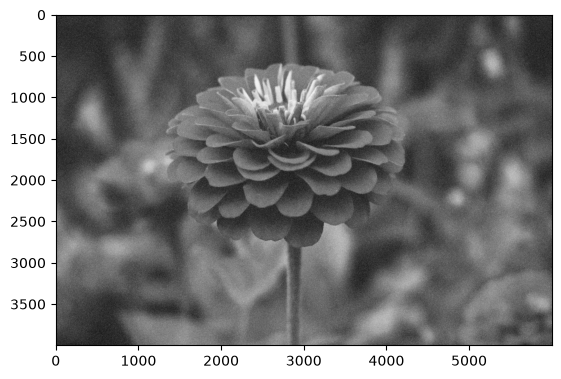

In [36]:
plt.imshow(image_gauss_gauss, cmap="gray")

In [37]:
image_uniform_gauss = cv2.GaussianBlur(image_noise_uniform, (5,5), 0)

In [38]:
mse_uniform_gauss = mean_squared_error(image_gray, image_uniform_gauss)
rmse_uniform_gauss = np.sqrt(mse_uniform_gauss)
ssim_uniform_gauss = structural_similarity(image_gray, image_uniform_gauss)
print(f"SSIM: {ssim_uniform:.2f} -> {ssim_uniform_gauss:.2f} RMSE: {rmse_uniform:.2f} -> {rmse_uniform_gauss:.2f}")

SSIM: 0.07 -> 0.41 RMSE: 57.24 -> 50.16


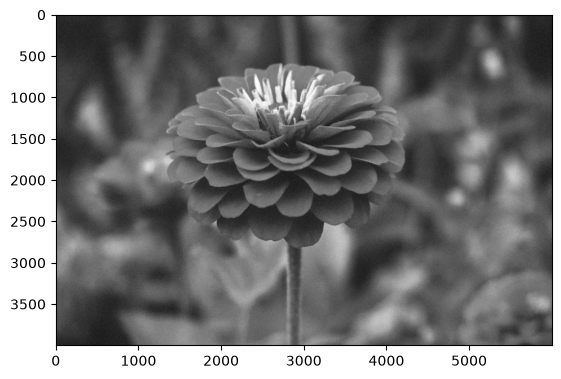

In [39]:
plt.imshow(image_uniform_gauss, cmap="gray")

In [40]:
image_gauss_gauss_up = cv2.GaussianBlur(image_noise_gauss, (9,9), 0)

In [41]:
mse_gauss_gauss_up = mean_squared_error(image_gray, image_gauss_gauss_up)
rmse_gauss_gauss_up = np.sqrt(mse_gauss_gauss_up)
ssim_gauss_gauss_up = structural_similarity(image_gray, image_gauss_gauss_up)
print(f"SSIM: {ssim_gauss_gauss:.2f} -> {ssim_gauss_gauss_up:.2f} RMSE: {rmse_gauss_gauss:.2f} -> {rmse_gauss_gauss_up:.2f}")

SSIM: 0.23 -> 0.42 RMSE: 41.61 -> 39.92


In [42]:
#Bilateral filter

In [43]:
image_gauss_bilateral = cv2.bilateralFilter(image_noise_gauss, d=9, sigmaColor=75, sigmaSpace=75)

In [44]:
mse_gauss_bilateral = mean_squared_error(image_gray, image_gauss_bilateral)
rmse_gauss_bilateral = np.sqrt(mse_gauss_bilateral)
ssim_gauss_bilateral = structural_similarity(image_gray, image_gauss_bilateral)
print(f"SSIM: {ssim_gauss:.2f} -> {ssim_gauss_bilateral:.2f} RMSE: {rmse_gauss:.2f} -> {rmse_gauss_bilateral:.2f}\n")

SSIM: 0.03 -> 0.10 RMSE: 67.09 -> 42.29



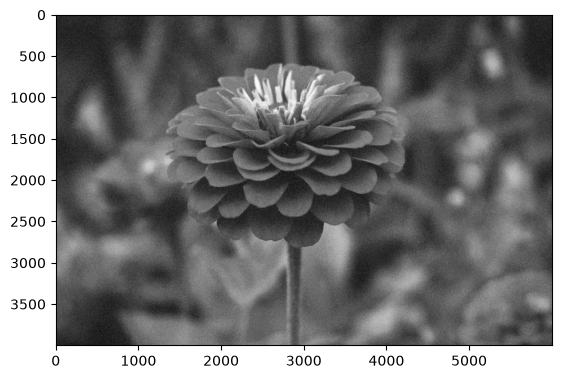

In [45]:
plt.imshow(image_gauss_bilateral, cmap="gray")

In [46]:
image_uniform_bilateral = cv2.bilateralFilter(image_noise_uniform, d=9, sigmaColor=75, sigmaSpace=75)

In [47]:
mse_uniform_bilateral = mean_squared_error(image_gray, image_uniform_bilateral)
rmse_uniform_bilateral = np.sqrt(mse_uniform_bilateral)
ssim_uniform_bilateral = structural_similarity(image_gray, image_uniform_bilateral)
print(f"SSIM: {ssim_uniform:.2f} -> {ssim_uniform_bilateral:.2f} RMSE: {rmse_uniform:.2f} -> {rmse_uniform_bilateral:.2f}")

SSIM: 0.07 -> 0.48 RMSE: 57.24 -> 49.90


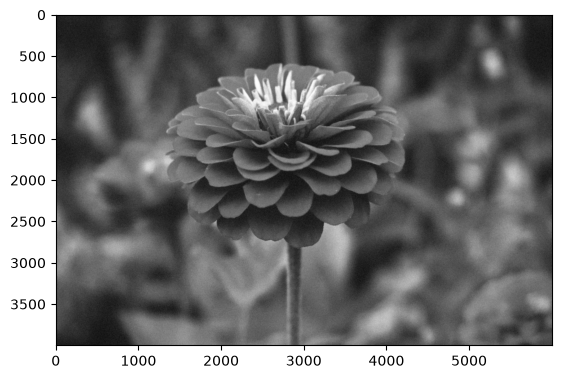

In [48]:
plt.imshow(image_uniform_bilateral, cmap="gray")

In [49]:
image_gauss_bilateral_up = cv2.bilateralFilter(image_noise_gauss, d=15, sigmaColor=150, sigmaSpace=150)

In [50]:
mse_gauss_bilateral_up = mean_squared_error(image_gray, image_gauss_bilateral_up)
rmse_gauss_bilateral_up = np.sqrt(mse_gauss_bilateral_up)
ssim_gauss_bilateral_up = structural_similarity(image_gray, image_gauss_bilateral_up)
print(f"SSIM: {ssim_gauss_bilateral:.2f} -> {ssim_gauss_bilateral_up:.2f} RMSE: {rmse_gauss_bilateral:.2f} -> {rmse_gauss_bilateral_up:.2f}")

SSIM: 0.10 -> 0.42 RMSE: 42.29 -> 36.22


In [51]:
#Non‑local mean filter

In [52]:
image_gauss_nl = cv2.fastNlMeansDenoising(image_noise_gauss, None, h=60, templateWindowSize=7, searchWindowSize=21)

In [53]:
mse_gauss_nl = mean_squared_error(image_gray, image_gauss_nl)
rmse_gauss_nl = np.sqrt(mse_gauss_nl)
ssim_gauss_nl = structural_similarity(image_gray, image_gauss_nl)

print(f"SSIM: {ssim_gauss:.2f} -> {ssim_gauss_nl:.2f} RMSE: {rmse_gauss:.2f} -> {rmse_gauss_nl:.2f}")

SSIM: 0.03 -> 0.61 RMSE: 67.09 -> 38.05


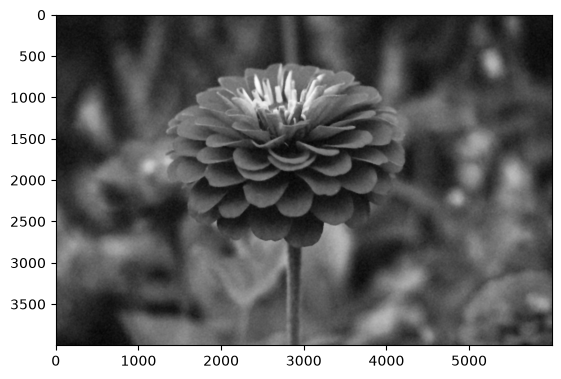

In [54]:
plt.imshow(image_gauss_nl, cmap="gray")

In [55]:
image_uniform_nl = cv2.fastNlMeansDenoising(image_noise_uniform, None, h=60, templateWindowSize=7, searchWindowSize=21)

In [56]:
mse_uniform_nl = mean_squared_error(image_gray, image_uniform_nl)
rmse_uniform_nl = np.sqrt(mse_uniform_nl)
ssim_uniform_nl = structural_similarity(image_gray, image_uniform_nl)

In [57]:
print(f"SSIM: {ssim_uniform:.2f} -> {ssim_uniform_nl:.2f} RMSE: {rmse_uniform:.2f} -> {rmse_uniform_nl:.2f}")

SSIM: 0.07 -> 0.61 RMSE: 57.24 -> 49.62


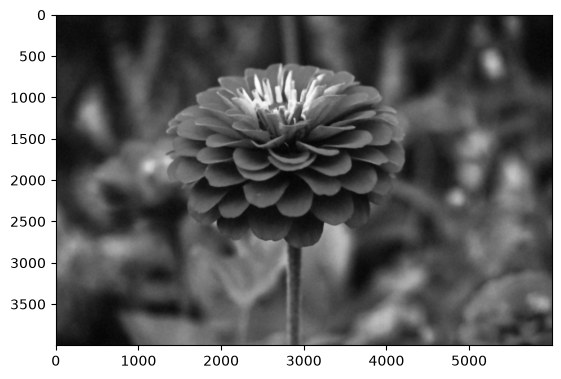

In [58]:
plt.imshow(image_uniform_nl, cmap="gray")

In [59]:
image_gauss_nl_high = cv2.fastNlMeansDenoising(image_noise_gauss, None, h=80, templateWindowSize=7, searchWindowSize=21)

In [60]:
mse_gauss_nl_high = mean_squared_error(image_gray, image_gauss_nl_high)
rmse_gauss_nl_high = np.sqrt(mse_gauss_nl_high)
ssim_gauss_nl_high = structural_similarity(image_gray, image_gauss_nl_high)

print(f"SSIM: {ssim_gauss_nl:.2f} -> {ssim_gauss_nl_high:.2f} RMSE: {rmse_gauss_nl:.2f} -> {rmse_gauss_nl_high:.2f}")

SSIM: 0.61 -> 0.64 RMSE: 38.05 -> 38.42


In [61]:
import pandas as pd

data = [
    # 1. MEDIAN FILTER
    {
        "Noise Type": "Uniform",
        "Filter": "Median Filter",
        "Parameters": "kernel=3",
        "SSIM": 0.19,
        "RMSE": 51.77,
    },
    {
        "Noise Type": "Uniform",
        "Filter": "Median Filter",
        "Parameters": "kernel=5",
        "SSIM": 0.34,
        "RMSE": 50.52,
    },
    {
        "Noise Type": "Gaussian",
        "Filter": "Median Filter",
        "Parameters": "kernel=3",
        "SSIM": 0.15,
        "RMSE": 29.03,
    },

    # 2. GAUSSIAN FILTER
    {
        "Noise Type": "Gaussian",
        "Filter": "Gaussian Blur",
        "Parameters": "kernel=(5, 5)",
        "SSIM": 0.23,
        "RMSE": 41.57,
    },
    {
        "Noise Type": "Gaussian",
        "Filter": "Gaussian Blur",
        "Parameters": "kernel=(9, 9)",
        "SSIM": 0.42,
        "RMSE": 39.88,
    },
    {
        "Noise Type": "Uniform",
        "Filter": "Gaussian Blur",
        "Parameters": "kernel=(5, 5)",
        "SSIM": 0.40,
        "RMSE": 50.15,
    },

    # 3. BILATERAL FILTER
    {
        "Noise Type": "Gaussian",
        "Filter": "Bilateral Filter",
        "Parameters": "d=9, sColor=75, sSpace=75",
        "SSIM": 0.10,
        "RMSE": 42.24,
    },
    {
        "Noise Type": "Gaussian",
        "Filter": "Bilateral Filter",
        "Parameters": "d=15, sColor=150, sSpace=150",
        "SSIM": 0.42,
        "RMSE": 36.18,
    },
    {
        "Noise Type": "Uniform",
        "Filter": "Bilateral Filter",
        "Parameters": "d=9, sColor=75, sSpace=75",
        "SSIM": 0.48,
        "RMSE": 49.90,
    },

    # 4. NON-LOCAL MEANS FILTER
    {
        "Noise Type": "Gaussian",
        "Filter": "Non-Local Means",
        "Parameters": "h=60, template=7, search=21",
        "SSIM": 0.61,
        "RMSE": 38.05,
    },
    {
        "Noise Type": "Gaussian",
        "Filter": "Non-Local Means",
        "Parameters": "h=80, template=7, search=21",
        "SSIM": 0.64,
        "RMSE": 38.42,
    },
    {
        "Noise Type": "Uniform",
        "Filter": "Non-Local Means",
        "Parameters": "h=60, template=7, search=21",
        "SSIM": 0.61,
        "RMSE": 49.62,
    }
]

df_results = pd.DataFrame(data)
display(df_results)

,Noise Type,Filter,Parameters,SSIM,RMSE
0,Uniform,Median Filter,kernel=3,0.19,51.77
1,Uniform,Median Filter,kernel=5,0.34,50.52
2,Gaussian,Median Filter,kernel=3,0.15,29.03
3,Gaussian,Gaussian Blur,"kernel=(5, 5)",0.23,41.57
4,Gaussian,Gaussian Blur,"kernel=(9, 9)",0.42,39.88
5,Uniform,Gaussian Blur,"kernel=(5, 5)",0.40,50.15
6,Gaussian,Bilateral Filter,"d=9, sColor=75, sSpace=75",0.10,42.24
7,Gaussian,Bilateral Filter,"d=15, sColor=150, sSpace=150",0.42,36.18
8,Uniform,Bilateral Filter,"d=9, sColor=75, sSpace=75",0.48,49.90
9,Gaussian,Non-Local Means,"h=60, template=7, search=21",0.61,38.05


In [ ]:
# The best result for Gaussian noise filtering is Non-Local Means
# The best result for Uniform noise filtering is Non-Local Means